In [1]:
import numpy as np
import rebound as rb
import einsteinpy.symbolic as es    
import scipy as sp 
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sm
import pymcel as pc 
from pymcel import constantes as const




c:\Users\User\OneDrive\Documentos\Relatividad\.venv\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.6) doesn't match a supported version!
  warnings.warn(


Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


### Sistema de Unidades Geometrizadas

Para simplificar el cálculo numérico de las geodésicas y evitar inconsistencias de escala computacional, adoptamos el sistema de unidades geometrizadas, en el cual se define:

$$G = c = 1$$

Bajo este sistema, la masa $M$ del agujero negro define las escalas fundamentales de longitud y tiempo del problema. La Unidad de Longitud ($UL$) corresponde al radio gravitacional:

$$1 \text{ UL} = \frac{GM}{c^2}$$

De igual manera, la Unidad de Tiempo ($UT$) se define como el tiempo que tarda la luz en recorrer dicha distancia:

$$1 \text{ UT} = \frac{UL}{c} = \frac{GM}{c^3}$$

En estas unidades, el Radio de Schwarzschild para un agujero negro estático viene dado por $R_s = 2M$. 

**Nota computacional:** En los experimentos numéricos de este cuaderno estableceremos $M = 1$. Esto implica que todas las distancias y tiempos en nuestras simulaciones y gráficos estarán expresados implícitamente en múltiplos de la masa del agujero negro (por ejemplo, una coordenada radial $r = 6$ corresponderá a $r = 6M$).

In [2]:
# Definimos unidades basadas en un agujero negro de masa solar (M=1)
c = 1.0  # Velocidad de la luz [6]
G = 1.0  # Constante de gravitación [4]
M = 1.0  # Masa del objeto central

# Unidad de longitud (UL) = Radio gravitacional (GM/c^2)
UL = G * M / c**2 
# Unidad de tiempo (UT) = UL / c
UT = UL / c 

### Geodésicas en el Límite Newtoniano (Campo Débil)

En esta sección se establece el caso base clásico para comparar con las correcciones relativistas. Se implementa la dinámica de partículas en un campo débil bajo unidades geometrizadas.

Para establecer una base comparativa con los efectos relativistas puros, modelamos el comportamiento de las partículas mediante una métrica de campo débil (aproximación Newtoniana). Adoptando la signatura principalmente negativa $(+, -, -, -)$ vista en clase y nuestro sistema de unidades geometrizadas ($G=c=1$), el tensor métrico adopta la forma:

$$ds^2 = \left(1 - \frac{2M}{r}\right)dt^2 - dx^2 - dy^2 - dz^2$$

Utilizando la ecuación de la geodésica $\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta}U^\alpha U^\beta = 0$, deducimos los símbolos de Christoffel relevantes para el movimiento. La evolución temporal del factor de Lorentz de la partícula ($U^t$) queda determinada por:

$$\frac{dU^t}{d\tau} = -\frac{2M U^t}{r^2(r - 2M)} (xU^x + yU^y + zU^z)$$

Mientras que para las componentes espaciales, la ecuación geodésica exacta para esta métrica nos da:

$$\frac{dU^i}{d\tau} = -\frac{M}{r^3}x^i (U^t)^2$$

*(Nota física: En el límite estrictamente clásico donde las velocidades son pequeñas respecto a la luz, el factor de Lorentz $U^t \approx 1$, por lo que recuperamos exactamente la aceleración gravitacional Newtoniana $\frac{d^2x^i}{dt^2} \approx -\frac{M}{r^3}x^i$. Sin embargo, en nuestras simulaciones numéricas conservaremos el término $(U^t)^2$ para que la integración paso a paso respecto al tiempo propio $\tau$ sea matemáticamente coherente con la métrica).*

In [3]:
def edg_newton(tau, Ys, G, M, c):
    """
    Ecuaciones diferenciales para la trayectoria en el límite Newtoniano/Campo Débil.
    Escritas de forma explícita para cada componente (sin factor común).
    Ys contiene: [T, x, y, z, Ut, Ux, Uy, Uz] donde T = c*t
    """
    T, x, y, z, Ut, Ux, Uy, Uz = Ys
    r = np.sqrt(x**2 + y**2 + z**2)
    
    # Evitar división por cero si la partícula cae al centro
    if r < 1e-5:
        return [0]*8
    
    # Derivadas de las coordenadas (Cuadrivelocidad)
    dT_dtau = Ut
    dx_dtau = Ux
    dy_dtau = Uy
    dz_dtau = Uz
    
    # Componente temporal: dUt/dtau (Derivada de U^T)
    denom = (c**2 * r - 2 * G * M) * r**2
    dUt_dtau = -2 * G * M * Ut * (x*Ux + y*Uy + z*Uz) / denom
    
    # Componentes espaciales: dUi/dtau (Derivada de U^i)
    
    dUx_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * x
    dUy_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * y
    dUz_dtau = -(G * M / (c**2 * r**3)) * (Ut**2) * z
    
    return [dT_dtau, dx_dtau, dy_dtau, dz_dtau, dUt_dtau, dUx_dtau, dUy_dtau, dUz_dtau]

### Determinación de las Condiciones Iniciales y Normalización

Para iniciar la integración numérica de las geodésicas, es fundamental que el vector de estado inicial cumpla con la restricción de normalización de la cuadrivelocidad para partículas con masa. Utilizando la signatura principalmente negativa $(+, -, -, -)$, esta restricción viene definida por el invariante:

$$g_{\mu\nu} U^\mu U^\nu = c^2$$

Dado que conocemos la posición inicial $r_0$ y la velocidad espacial tridimensional respecto al tiempo coordenado $\vec{v} = (v^x, v^y, v^z)$, podemos relacionar las componentes espaciales de la cuadrivelocidad mediante $U^i = U^t \frac{v^i}{c}$ (o simplemente $U^i = U^t v^i$ en unidades relativistas donde $c=1$). 

Sustituyendo esta relación en la condición de normalización para una métrica espacialmente plana:

$$g_{00} (U^t)^2 - \delta_{ij} (U^t v^i)(U^t v^j) = c^2$$

Factorizando $(U^t)^2$ en el miembro izquierdo de la ecuación obtenemos:

$$(U^t)^2 \left( g_{00} - |\vec{v}|^2 \right) = c^2$$

Despejando la componente temporal $U^t$, obtenemos la ecuación que garantiza condiciones iniciales físicamente consistentes y evita soluciones imaginarias bajo el radical:

$$U^t_0 = \frac{c}{\sqrt{g_{00} - |\vec{v}|^2}}$$

En el sistema de unidades canónicas adoptado para la simulación ($c = 1, G = 1$), la expresión final se reduce a:

$$U^t_0 = \frac{1}{\sqrt{g_{00} - |\vec{v}|^2}}$$

In [4]:
t0 = 0.0
# Posición inicial de la partícula en el plano ecuatorial (UL)
x0, y0, z0 = 10.0, 0.0, 0.0
r0 = np.sqrt(x0**2 + y0**2 + z0**2)

# Velocidad inicial de coordenadas dada como fracción de c (adimensional)
vx0, vy0, vz0 = 0.0, 0.25, 0.0 
v_sq = vx0**2 + vy0**2 + vz0**2

# Componentes del tensor métrico inicial
g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
g11 = g22 = g33 = -1.0  # Espacio tridimensional plano y negativo

# Cálculo de la componente temporal de la cuadrivelocidad (U^T)

Ut0 = c / np.sqrt(g00 - v_sq)

# Transformación a las componentes espaciales de la cuadrivelocidad

Ux0 = vx0 * Ut0
Uy0 = vy0 * Ut0
Uz0 = vz0 * Ut0

# Vector de estado inicial para el integrador (solve_ivp): [T, x, y, z, Ut, Ux, Uy, Uz]

Y0 = [c * t0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]

### Integración Numérica de las Ecuaciones Geodésicas

La evolución del estado de la partícula se obtiene integrando numéricamente un sistema acoplado de ocho ecuaciones diferenciales ordinarias de primer orden, donde la variable independiente es el tiempo propio $\tau$:

$$
\frac{d x^\mu}{d\tau} = U^\mu, \quad \frac{d U^\mu}{d\tau} = -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta
$$

**Tiempo de Simulación (Tercera Ley de Kepler)**
Para que el intervalo de integración tenga sentido físico y nos permita observar exactamente una revolución completa de la partícula en el espacio, calculamos el período orbital clásico $T$ mediante la Tercera Ley de Kepler como límite final ($\tau_{\text{final}}$):

$$\tau_{\text{final}} = T = 2\pi \sqrt{\frac{r_0^3}{GM}}$$

**Método y Tolerancias**
Para resolver este sistema, empleamos el **método de Radau** mediante la función `solve_ivp`. Este esquema implícito se elige por su excelente estabilidad para resolver ecuaciones numéricamente rígidas (*stiff*), una condición típica en trayectorias de alta curvatura.

Para garantizar que el integrador conserve los invariantes físicos (energía, momento angular y la norma de la cuadrivelocidad $g_{\mu\nu}U^\mu U^\nu = c^2$), imponemos tolerancias de convergencia estrictas:
* **Tolerancia relativa (`rtol`):** $10^{-9}$
* **Tolerancia absoluta (`atol`):** $10^{-12}$

In [5]:
#  TIEMPO DE INTEGRACIÓN 

T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))

# Definimos el intervalo de integración (integraremos durante 1 período orbital completo)
tau_final = T_kepler
taus = np.linspace(0, tau_final, 2000)

#  INTEGRACIÓN NUMÉRICA 

solucion = solve_ivp(
    edg_newton, 
    [0.0, tau_final], 
    Y0, 
    args=(G, M, c), 
    t_eval=taus, 
    method='Radau',
    rtol=1e-9,   # Tolerancia relativa estricta para conservar constantes de movimiento
    atol=1e-12   # Tolerancia absoluta estricta
)


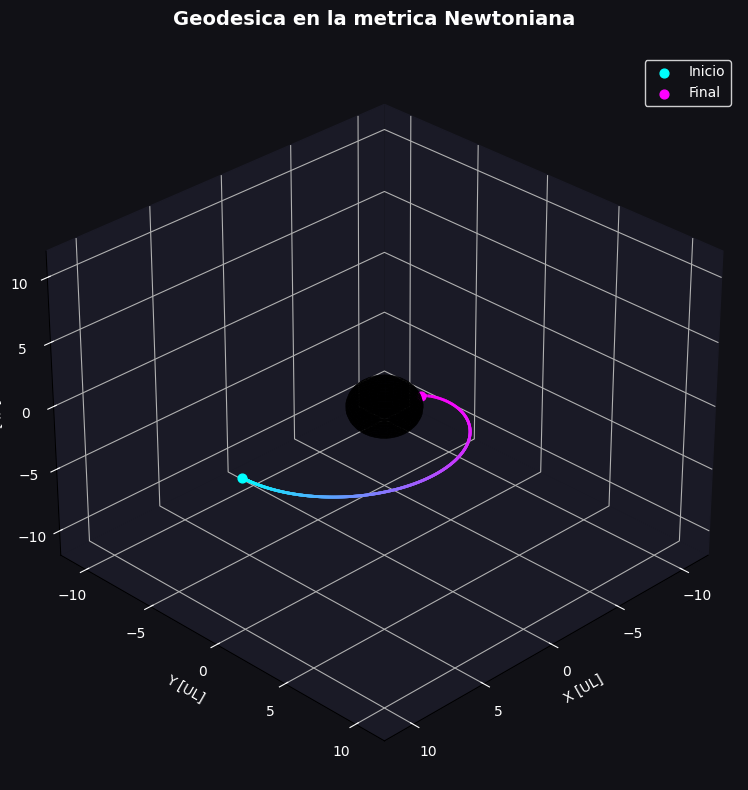

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- EXTRAER COORDENADAS DE LA PARTÍCULA DE CONTROL ---
x_p = solucion.y[1]
y_p = solucion.y[2]
z_p = solucion.y[3]
N_puntos = len(x_p)

# --- CREAR LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Configuración del ángulo de visión (puedes ajustarlo a tu gusto)
ax.view_init(elev=30, azim=45)

# --- GRAFICAR LA TRAYECTORIA CON DEGRADADO (COLORMAP) ---
# Usamos un truco: graficamos pequeños segmentos para que cambien de color con el tiempo
# El color 'cool' va desde cyan (inicio) hasta magenta/rosado (final de la órbita)
cmap = plt.get_cmap('cool')
for i in range(N_puntos - 1):
    ax.plot(x_p[i:i+2], y_p[i:i+2], z_p[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.8, linewidth=2.0)

# Marcamos explícitamente el punto inicial y final
ax.scatter(x_p[0], y_p[0], z_p[0], color='cyan', s=40, label='Inicio', zorder=5)
ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='magenta', s=40, label='Final', zorder=5)

# --- DIBUJAR LA MASA CENTRAL (Radio de Schwarzschild como escala) ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA EN FONDO OSCURO ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

# Oscurecer los planos de los ejes
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

# Etiquetas de los ejes
ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales basados en la posición inicial (con un margen)
lim = max(np.max(np.abs(x_p)), np.max(np.abs(y_p))) * 1.2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

# Título y leyenda
plt.title('Geodesica en la metrica Newtoniana', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Integración de Múltiples Partículas

Se generaliza el procedimiento anterior para un conjunto de trayectorias con condiciones iniciales distribuidas en un disco. Esto permite visualizar la estructura global del sistema y sus tendencias dinámicas.

In [7]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
resultados_disco_3d = [] # Aquí guardaremos todas las órbitas

# Límites del disco: Radio interno y externo 
r_min = 5.0
r_max = 15.0



for i in range(N_particulas):
    # 1. Posición inicial aleatoria en el plano (z=0)
    r0 = np.random.uniform(r_min, r_max)
    phi = np.random.uniform(0, 2 * np.pi) 
    
    x0 = r0 * np.cos(phi)
    y0 = r0 * np.sin(phi)
    z0 = 0.0
    
    # Velocidad inicial (Órbita circular Kepleriana clásica)
    # v = sqrt(GM/r). La proyectamos perpendicular al radio vector.
    v_mag = np.sqrt(G * M / r0)
    vx0 = -v_mag * np.sin(phi)
    vy0 = v_mag * np.cos(phi)
    vz0 = 0.0
    
    # Normalización y Cuadrivelocidad inicial (documento del profesor)
    g00 = 1.0 - (2.0 * G * M) / (c**2 * r0)
    g11 = g22 = g33 = -1.0
    
    Ut0 = 1.0 / np.sqrt(g00 + g11*vx0**2 + g22*vy0**2 + g33*vz0**2)
    Ux0 = vx0 * Ut0 / c
    Uy0 = vy0 * Ut0 / c
    Uz0 = vz0 * Ut0 / c
    
    Y0 = [0.0, x0, y0, z0, Ut0, Ux0, Uy0, Uz0]
    
    # Tiempo de integración (1 órbita completa exacta por partícula usando Kepler)
    T_kepler = 2 * np.pi * np.sqrt(r0**3 / (G * M))
    # Reducimos los puntos a 200 por órbita para no saturar la memoria gráfica con 500 líneas
    taus = np.linspace(0, T_kepler, 200) 
    
    # 5. Integración numérica
    sol = solve_ivp(
        edg_newton, 
        [0.0, T_kepler], 
        Y0, 
        args=(G, M, c), 
        t_eval=taus, 
        method='Radau',
        rtol=1e-7,  # Relajamos un poco las tolerancias para hacer más rápida la ejecución masiva
        atol=1e-10
    )
    
    # Guardamos la trayectoria en la lista
    resultados_disco_3d.append(sol.y)
    


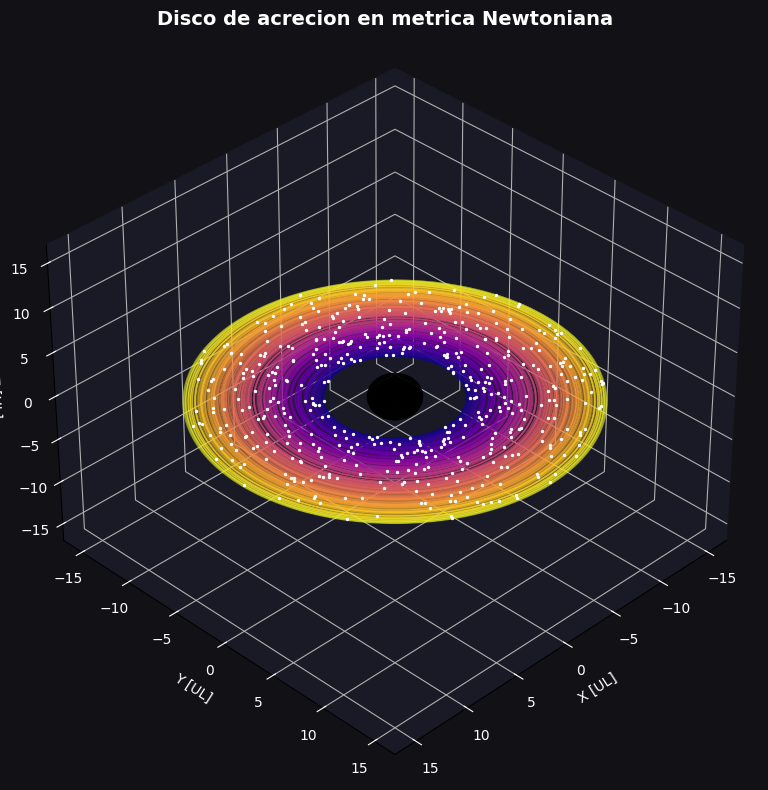

In [8]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# --- CONFIGURACIÓN DEL ÁNGULO ---
ax.view_init(elev=35, azim=45)

# --- DIBUJAR LAS 500 PARTÍCULAS ---
# Usamos un mapa de colores 'plasma' (naranja/morado) para colorearlas según su distancia
colores = cm.plasma(np.linspace(0, 1, len(resultados_disco_3d)))

for idx, y_particula in enumerate(resultados_disco_3d):
    x_p = y_particula[1]
    y_p = y_particula[2]
    z_p = y_particula[3]
    
    # Calculamos el radio promedio para darle color
    r_promedio = np.mean(np.sqrt(x_p**2 + y_p**2))
    color_asignado = cm.plasma((r_promedio - r_min) / (r_max - r_min))
    
    ax.plot(x_p, y_p, z_p, color=color_asignado, alpha=0.3, linewidth=0.8)
    ax.scatter(x_p[-1], y_p[-1], z_p[-1], color='white', s=2) # Puntos finales como "estrellas" o rocas

# --- DIBUJAR LA MASA CENTRAL ---
radio_horizonte = 2.0 * G * M / (c**2)
u = np.linspace(0, 2 * np.pi, 30)
v = np.linspace(0, np.pi, 30)
x_bh = radio_horizonte * np.outer(np.cos(u), np.sin(v))
y_bh = radio_horizonte * np.outer(np.sin(u), np.sin(v))
z_bh = radio_horizonte * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.9, zorder=10)

# --- CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')

ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [UL]', color='white')
ax.set_ylabel('Y [UL]', color='white')
ax.set_zlabel('Z [UL]', color='white')
ax.tick_params(colors='white')

# Forzar ejes proporcionales
lim = r_max + 2
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Disco de acrecion en metrica Newtoniana', 
          color='white', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Geodésicas en la Métrica de Schwarzschild

Para estudiar la dinámica de partículas en regiones donde el campo gravitacional es intenso (como las cercanías del agujero negro central en nuestro disco de acreción), la aproximación Newtoniana deja de ser válida y debemos utilizar la métrica exacta de Schwarzschild.

La métrica de Schwarzschild (bajo la signatura $+,-,-,-$) se escribe en coordenadas esféricas $(t, r, \theta, \phi)$ como:

$$
\mathrm{d}s^2 = \left(1-\frac{2GM}{c^2 r}\right) c^2 \mathrm{d}t^2 - \left(1-\frac{2GM}{c^2 r}\right)^{-1}\mathrm{d}r^2 - r^2\mathrm{d}\theta^2 - r^2\sin^2\theta \mathrm{d}\phi^2
$$

A partir de esta métrica, podemos derivar los símbolos de Christoffel que dictan las ecuaciones de la geodésica.

In [9]:
G, M, c, T, r, teta, fi = sm.symbols('G M c T r theta phi')

gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sm.sin(teta)**2])
coordenadas = T, r, teta, fi
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(gmet.tensor())
display(Gab.tensor())

[[-2*G*M/(c**2*r) + 1, 0, 0, 0], [0, -1/(-2*G*M/(c**2*r) + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

### Ecuación de Movimiento

A partir de los símbolos de Christoffel obtenidos, construimos el sistema de ecuaciones diferenciales ordinarias de primer orden para nuestro integrador numérico. 

Siguiendo las indicaciones, a partir de este punto utilizaremos **unidades canónicas** donde $G = 1$ y $c = 1$. Esto implica que la masa $M$ define la escala de longitud y tiempo del sistema, de modo que el radio de Schwarzschild se reduce simplemente a $r_s = 2M$.

In [10]:
def edg_schwarzschild(tau, Ys, M):
    """
    Sistema de Ecuaciones Diferenciales Ordinarias para las geodésicas 
    en la métrica de Schwarzschild usando unidades donde G=1 y c=1.
    """
    # Desempaquetar el vector de estado
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys
    
    # Radio de Schwarzschild en unidades canónicas
    rs = 2 * M
    
    # 1. Derivadas de las coordenadas (es simplemente la cuadrivelocidad)
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi
    
    # 2. Derivadas de las componentes de la cuadrivelocidad (Ecuación geodésica)
    # dU^σ/dτ = - Γ^σ_{μν} U^μ U^ν
    
    # Componente t
    dUt_dtau = - (rs / (r * (r - rs))) * Ut * Ur
    
    # Componente r
    dUr_dtau = (- (rs * (r - rs) / (2 * r**3)) * Ut**2 
                + (rs / (2 * r * (r - rs))) * Ur**2 
                + (r - rs) * Utheta**2 
                + (r - rs) * np.sin(theta)**2 * Uphi**2)
    
    # Componente theta
    dUtheta_dtau = (- (2 / r) * Ur * Utheta 
                    + np.sin(theta) * np.cos(theta) * Uphi**2)
    
    # Componente phi
    dUphi_dtau = (- (2 / r) * Ur * Uphi 
                  - 2 * (np.cos(theta) / np.sin(theta)) * Utheta * Uphi)
    
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau, 
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

### Verificación rápida

Se evalúa la función con un estado de prueba para confirmar que las derivadas se calculan sin errores.

In [11]:
test_estado = [0.0, 10.0, np.pi/2, 0.0, 1.0, 0.0, 0.0, 0.1]
prueba_derivadas = edg_schwarzschild(0, test_estado, M=1.0)


prueba_derivadas

[1.0,
 0.0,
 0.0,
 0.1,
 -0.0,
 np.float64(0.07200000000000001),
 np.float64(6.123233995736767e-19),
 np.float64(-0.0)]

### Solución a las ecuaciones geodésica

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = c = 1$) donde la masa central dicta la escala del sistema ($M = 1$), procedemos a establecer las condiciones iniciales para integrar la órbita.

A diferencia de la mecánica clásica, en Relatividad General las componentes de la velocidad inicial no son completamente arbitrarias. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer en todo momento la condición de normalización sobre la métrica:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado inicial de posición $(t_0, r_0, \theta_0, \phi_0)$ y unas velocidades espaciales iniciales $(U^r, U^\theta, U^\phi)$, estamos obligados a calcular la componente temporal de la cuadrivelocidad $U^t$ despejándola de la ecuación anterior. Para la métrica de Schwarzschild, esto resulta en:

$$U^t = \sqrt{\frac{1 - g_{rr}(U^r)^2 - g_{\theta\theta}(U^\theta)^2 - g_{\phi\phi}(U^\phi)^2}{g_{tt}}}$$

Con esta precaución física, garantizamos que la partícula arranque su trayectoria respetando la geometría del espacio-tiempo curvado.

### Condiciones iniciales en el espacio-tiempo

Recordando que ya hemos adoptado nuestro sistema de unidades geometrizadas ($G = 1, c = 1, M=1$), procedemos a establecer las condiciones iniciales. Para una partícula masiva, la cuadrivelocidad $U^\mu$ debe satisfacer la condición de normalización:

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Dado un estado espacial inicial, despejamos la componente temporal $U^t$ para garantizar que la partícula respete la geometría del espacio-tiempo.

### Tiempos y condiciones iniciales: ¿Por cuánto tiempo integrar?
Vamos a usar la tercera ley de Kepler: $n^2 a^3 = \mu$. 
En nuestras unidades canónicas donde $\mu = M = 1$, el período orbital aproximado viene dado por $T_{kepler} = 2\pi \sqrt{r^3}$. Utilizaremos este tiempo como referencia para integrar varias órbitas y observar los efectos relativistas (como la precesión del perihelio).

In [12]:
# PARÁMETROS DEL SISTEMA 
M = 1.0             # Masa 
rs = 2.0 * M        # Radio de Schwarzschild

# POSICIÓN Y VELOCIDAD ESPACIAL INICIAL 
t0 = 0.0
r0 = 10.0 * M       # Arrancamos a 10 veces la masa de distancia
theta0 = np.pi / 2  # Plano ecuatorial 
phi0 = 0.0          # Ángulo azimutal inicial

# Velocidades iniciales 
Ur0 = 0.0           # Sin velocidad radial inicial 
Utheta0 = 0.0       # Sin movimiento vertical 
Uphi0 = 0.035       # Velocidad angular inicial.

#### Cálculo de las cuadrivelocidades iniciales

A partir de la condición de normalización, se determina `U^t` y se arma el vector de estado inicial consistente con la métrica.

In [13]:
g00 = (1.0 - rs / r0)
g11 = -1.0 / (1.0 - rs / r0)
g22 = -r0**2
g33 = -r0**2 * np.sin(theta0)**2

# Despejamos Ut garantizando que la norma sea 1 (partícula masiva)
Ut0 = np.sqrt((1.0 - (g11 * Ur0**2 + g22 * Utheta0**2 + g33 * Uphi0**2)) / g00)

# Empaquetamos el estado inicial completo
Y0 = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

#### Integración numérica

Se integra el sistema de ecuaciones usando el mismo esquema y tolerancias adoptados en las secciones anteriores.

In [14]:
T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)

# Vamos a integrar por 3 "años" keplerianos para ver bien la órbita
tau_final = 3.0 * T_kepler  
taus = np.linspace(0, tau_final, 5000)


sol_schwarzschild = solve_ivp(
    edg_schwarzschild, 
    [0.0, tau_final], 
    Y0, 
    args=(M,), 
    t_eval=taus, 
    method='Radau', 
    rtol=1e-9,      
    atol=1e-12
)

### Extracción de la solución y Graficación

El integrador numérico nos ha devuelto la evolución del vector de estado en función del tiempo propio $\tau$. Sin embargo, las coordenadas espaciales se encuentran en formato esférico $(r, \theta, \phi)$. 

Para visualizar la trayectoria en el espacio tridimensional, debemos aplicar la transformación estándar a coordenadas cartesianas:

$$x = r \sin(\theta) \cos(\phi)$$
$$y = r \sin(\theta) \sin(\phi)$$
$$z = r \cos(\theta)$$

A continuación, extraemos estos datos, aplicamos la transformación y graficamos la órbita geodésica.

In [15]:
r_sol = sol_schwarzschild.y[1]
theta_sol = sol_schwarzschild.y[2]
phi_sol = sol_schwarzschild.y[3]

# Transformamos a cartesianas
x_sol = r_sol * np.sin(theta_sol) * np.cos(phi_sol)
y_sol = r_sol * np.sin(theta_sol) * np.sin(phi_sol)
z_sol = r_sol * np.cos(theta_sol)
N_puntos = len(x_sol)

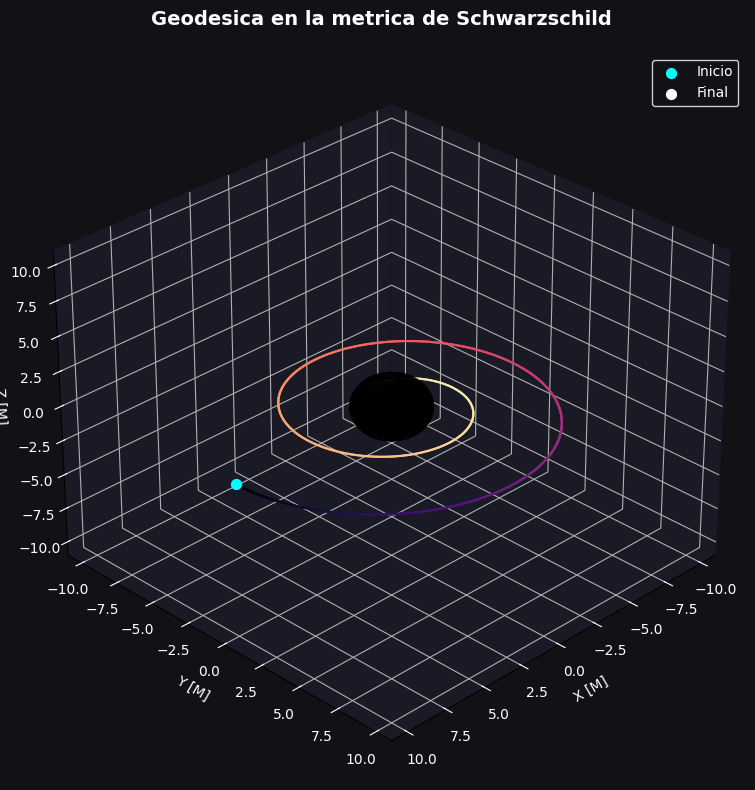

In [16]:
# --- 2. CONFIGURACIÓN DE LA FIGURA 3D ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=30, azim=45) # Ángulo de visión

# --- 3. DIBUJAR LA GEODÉSICA (Con mapa de color temporal) ---
# Usamos un mapa de colores 'magma' para ver la evolución (de oscuro a brillante)
cmap = plt.get_cmap('magma')
for i in range(N_puntos - 1):
    ax.plot(x_sol[i:i+2], y_sol[i:i+2], z_sol[i:i+2], 
            color=cmap(i / N_puntos), alpha=0.9, linewidth=1.5)

# Puntos de inicio y fin
ax.scatter(x_sol[0], y_sol[0], z_sol[0], color='cyan', s=50, label='Inicio', zorder=5)
ax.scatter(x_sol[-1], y_sol[-1], z_sol[-1], color='white', s=50, label='Final', zorder=5)

# --- 4. DIBUJAR EL AGUJERO NEGRO (Horizonte de Eventos) ---
# En nuestras unidades, rs = 2.0 * M
rs_grafico = 2.0 * M
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_grafico * np.outer(np.cos(u), np.sin(v))
y_bh = rs_grafico * np.outer(np.sin(u), np.sin(v))
z_bh = rs_grafico * np.outer(np.ones(np.size(u)), np.cos(v))

ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# --- 5. CONFIGURACIÓN ESTÉTICA ---
ax.set_facecolor('#111116')
fig.patch.set_facecolor('#111116')
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

# Límites dinámicos para que la órbita quepa perfecta
lim = max(np.max(np.abs(x_sol)), np.max(np.abs(y_sol))) * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Geodesica en la metrica de Schwarzschild', 
          color='white', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', facecolor='#111116', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

### Simulación de un Disco de Acreción Relativista

Habiendo comprobado la correcta integración de una geodésica individual, procedemos a simular un ensamble estelar o disco de polvo alrededor del agujero negro. 

A diferencia del caso Newtoniano, la Relatividad General impone un límite físico estricto conocido como la Órbita Circular Estable Más Interna (ISCO). Para la métrica de Schwarzschild, la ISCO se ubica en $r = 6M$. Las partículas con radios menores a este límite no pueden mantener órbitas circulares estables y precipitan hacia el horizonte de eventos. 

Por lo tanto, distribuiremos aleatoriamente 500 partículas en el plano ecuatorial ($\theta = \pi/2$) con radios comprendidos entre $r_{min} = 6M$ y un $r_{max}$ arbitrario. Calcularemos la cuadrivelocidad temporal $U^t$ para cada una, garantizando que todo el disco respete la condición de normalización $g_{\mu\nu}U^\mu U^\nu = 1$, y visualizaremos el resultado transformando las coordenadas a un espacio cartesiano.

In [17]:
#  CONFIGURACIÓN DEL DISCO 
N_particulas = 500
M = 1.0
rs = 2.0 * M

r_min = 6.0 * M  
r_max = 20.0 * M 

# Listas para guardar las trayectorias cartesianas
resultados_x = []
resultados_y = []
resultados_z = []
radios_iniciales = []



# INTEGRACIÓN MASIVA 
for i in range(N_particulas):
    # Condiciones espaciales aleatorias
    r0 = np.random.uniform(r_min, r_max)
    phi0 = np.random.uniform(0, 2 * np.pi)
    theta0 = np.pi / 2  # Disco ecuatorial
    
    # Velocidades 
    Ur0 = 0.0
    Utheta0 = 0.0
    Uphi0 = np.sqrt(M / r0) / r0  # dphi/dtau
    
    # Cálculo de U^t para cada partícula
    g_00 = (1.0 - rs / r0)
    g_11 = -1.0 / (1.0 - rs / r0)
    g_22 = -r0**2
    g_33 = -r0**2
    
    Ut0 = np.sqrt((1.0 - (g_11*Ur0**2 + g_22*Utheta0**2 + g_33*Uphi0**2)) / g_00)
    Y0 = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]
    
    # Tiempo de integración 
    T_kepler = 2.0 * np.pi * np.sqrt(r0**3 / M)
    tau_final = 1.2 * T_kepler
    taus = np.linspace(0, tau_final, 100) # 100 puntos por partícula es suficiente
    
    # Integrador
    sol = solve_ivp(edg_schwarzschild, [0.0, tau_final], Y0, args=(M,), 
                    t_eval=taus, method='Radau', rtol=1e-5, atol=1e-8)
    
    # Extraer y transformar a cartesianas inmediatamente para no saturar memoria
    r_sol = sol.y[1]
    th_sol = sol.y[2]
    ph_sol = sol.y[3]
    
    resultados_x.append(r_sol * np.sin(th_sol) * np.cos(ph_sol))
    resultados_y.append(r_sol * np.sin(th_sol) * np.sin(ph_sol))
    resultados_z.append(r_sol * np.cos(th_sol))
    radios_iniciales.append(r0)
    


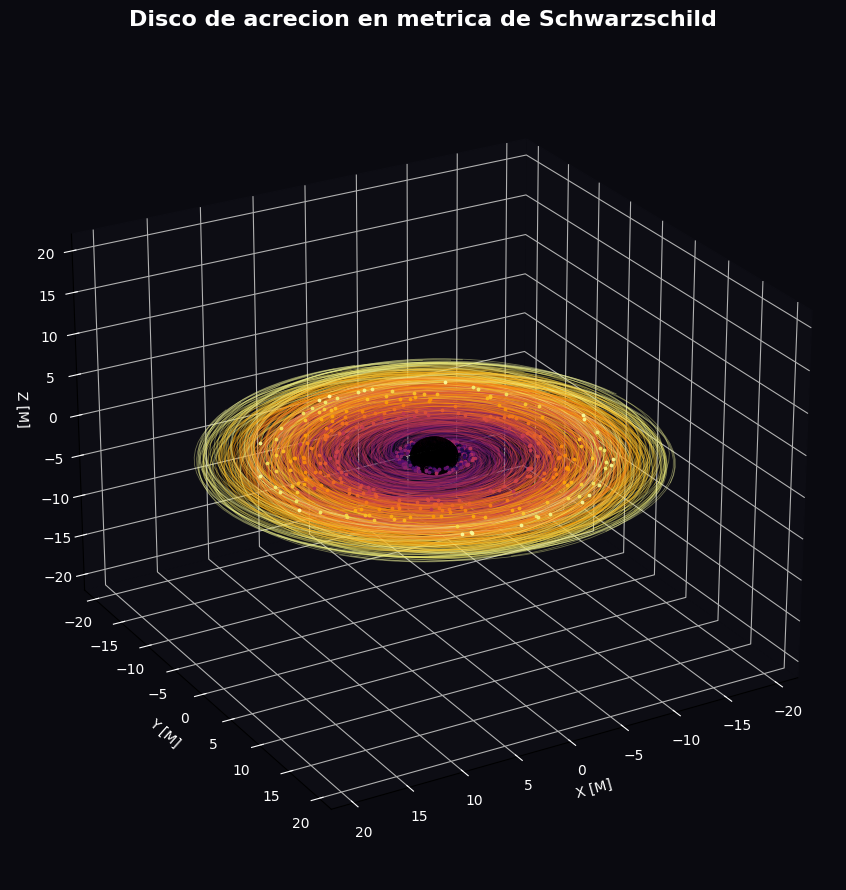

In [18]:
# --- 3. GRAFICACIÓN DEL DISCO 3D ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=25, azim=60)

# Colores basados en el radio inicial (gradiente térmico figurativo)
colores = cm.inferno((np.array(radios_iniciales) - r_min) / (r_max - r_min))

for i in range(N_particulas):
    ax.plot(resultados_x[i], resultados_y[i], resultados_z[i], 
            color=colores[i], alpha=0.4, linewidth=0.6)
    # Partícula final brillante
    ax.scatter(resultados_x[i][-1], resultados_y[i][-1], resultados_z[i][-1], 
               color=colores[i], s=3, alpha=0.9)

# Agujero Negro Central (r = 2M)
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs * np.outer(np.cos(u), np.sin(v))
y_bh = rs * np.outer(np.sin(u), np.sin(v))
z_bh = rs * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=1.0, zorder=10)

# Estética
ax.set_facecolor('#0a0a10')
fig.patch.set_facecolor('#0a0a10')
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel('X [M]', color='white')
ax.set_ylabel('Y [M]', color='white')
ax.set_zlabel('Z [M]', color='white')
ax.tick_params(colors='white')

lim = r_max * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title('Disco de acrecion en metrica de Schwarzschild', 
          color='white', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

## Métrica de Kerr: Agujeros Negros en Rotación

La métrica de Kerr es una solución exacta de las ecuaciones de campo de Einstein en el vacío que describe la geometría del espacio-tiempo alrededor de un cuerpo masivo, sin carga eléctrica, pero **en rotación** (con simetría axial). Dado que en el universo los objetos astrofísicos reales conservan momento angular al colapsar, la métrica de Kerr es el modelo más realista para estudiar fenómenos como los **discos de acreción** y los **jets relativistas**.

### Elemento de línea

Utilizando las **coordenadas de Boyer–Lindquist** $(t, r, \theta, \phi)$, el elemento de línea asume una forma que evita ciertas singularidades en los ejes y se expresa como:

$$ds^2 = \left(1 - \frac{R_s r}{\rho^2}\right) c^2 dt^2 + \frac{2 R_s r a \sin^2(\theta)}{\rho^2} c\, dt\, d\phi - \frac{\rho^2}{\Delta} dr^2 - \rho^2 d\theta^2 - \left( r^2 + a^2 + \frac{R_s r a^2 \sin^2(\theta)}{\rho^2} \right) \sin^2(\theta) d\phi^2$$

Donde hemos definido los siguientes parámetros y funciones auxiliares para simplificar la notación:

* **$R_s = \frac{2GM}{c^2}$**: Es el radio de Schwarzschild (relacionado con la masa $M$ del agujero negro).
* **$a = \frac{J}{Mc}$**: Es el parámetro de espín o momento angular por unidad de masa. Físicamente representa qué tan rápido rota el agujero negro.
* **$\rho^2 = r^2 + a^2 \cos^2(\theta)$**: Es una función geométrica que acopla la coordenada radial y la polar.
* **$\Delta = r^2 - R_s r + a^2$**: Es una función fundamental para determinar las singularidades coordenables (los horizontes).





In [19]:
# Definicion de los simbolos

G, M, c, t, r, theta, phi, a = sm.symbols('G M c t r theta phi a')

R_s = 2*G*M/c**2

Delta = r**2 - 2*G*M*r/c**2 + a**2
rho = r**2 + a**2 * sm.cos(theta)**2

### Componentes Geométricas de la Métrica de Kerr

Asumiendo unidades geometrizadas ($c = 1$, $G = 1$) y utilizando coordenadas de Boyer-Lindquist, los componentes covariantes del tensor métrico $g_{\mu\nu}$ se definen como:

$$
\begin{aligned}
g_{00} &= 1 - \frac{R_s r}{\rho^2} \\
g_{11} &= -\frac{\rho^2}{\Delta} \\
g_{22} &= -\rho^2 \\
g_{33} &= -\left(r^2 + a^2 + \frac{R_s r a^2 \sin^2\theta}{\rho^2}\right)\sin^2\theta \\
g_{03} &= g_{30} = \frac{R_s r a \sin^2\theta}{\rho^2}
\end{aligned}
$$

### Representación Matricial del Tensor Métrico de Kerr

En coordenadas de Boyer-Lindquist $(t, r, \theta, \phi)$ y usando unidades geometrizadas ($G=1, c=1$), el tensor métrico covariante $g_{\mu\nu}$ se puede representar como una matriz de $4 \times 4$. 

Debido a que el agujero negro es estacionario (no cambia con el tiempo) y tiene simetría axial (es simétrico respecto a su eje de rotación), muchos componentes son cero. La rotación introduce los términos cruzados fuera de la diagonal $g_{03}$ y $g_{30}$:

$$
g_{\mu\nu} = \begin{pmatrix}
g_{00} & 0 & 0 & g_{03} \\
0 & g_{11} & 0 & 0 \\
0 & 0 & g_{22} & 0 \\
g_{30} & 0 & 0 & g_{33}
\end{pmatrix}
$$

Reemplazando las expresiones geométricas correspondientes, la matriz exacta toma la siguiente forma:

$$
g_{\mu\nu} = \begin{pmatrix}
1 - \frac{R_s r}{\rho^2} & 0 & 0 & \frac{R_s r a \sin^2\theta}{\rho^2} \\
0 & -\frac{\rho^2}{\Delta} & 0 & 0 \\
0 & 0 & -\rho^2 & 0 \\
\frac{R_s r a \sin^2\theta}{\rho^2} & 0 & 0 & -\left(r^2 + a^2 + \frac{R_s r a^2 \sin^2\theta}{\rho^2}\right)\sin^2\theta
\end{pmatrix}
$$

In [20]:
g_00 = 1 - R_s * r / rho**2
g_11 = -rho**2 / Delta
g_22 = -rho**2
g_33 = - (r**2 + a**2 + R_s * r * a**2 * sm.sin(theta)**2 / rho**2) * sm.sin(theta)**2
g_03 = g_30 = R_s * r * a * sm.sin(theta)**2 / rho**2

### Representación Matricial del Tensor Métrico de Kerr

Se organiza el tensor covariante $g_{\mu\nu}$ en forma matricial para su uso en los cálculos simbólicos y numéricos posteriores.

In [21]:
g_kerr = sm.Matrix([
    [g_00, 0,    0,      g_03],
    [0,    g_11, 0,      0     ],
    [0,    0,    g_22, 0     ],
    [g_30, 0,  0,      g_33]
])

coordenadas = [t, r, theta, phi]

gmet = es.MetricTensor(g_kerr.tolist(), coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)

In [22]:
# Preparamos los simbolos de Christoffel para uso numerico (G=c=1).
Gamma_kerr = sm.simplify(Gab.tensor().subs({G: 1, c: 1}))
Gamma_kerr_func = sm.lambdify((r, theta, M, a), Gamma_kerr, "numpy")

def edg_kerr(tau, Ys, M_value, a_value):
    """
    Ecuaciones geodesicas para la metrica de Kerr en unidades G=c=1.
    Ys = [t, r, theta, phi, Ut, Ur, Utheta, Uphi].
    """
    t_val, r_val, theta_val, phi_val, Ut, Ur, Utheta, Uphi = Ys
    
    # Derivadas de coordenadas (cuadrivelocidad)
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi
    
    # Simbolos de Christoffel evaluados en (r, theta)
    Gamma = np.array(Gamma_kerr_func(r_val, theta_val, M_value, a_value), dtype=float)
    U = np.array([Ut, Ur, Utheta, Uphi], dtype=float)
    
    # dU^sigma/dtau = -Gamma^sigma_{mu nu} U^mu U^nu
    dU = np.zeros(4, dtype=float)
    for sigma in range(4):
        dU[sigma] = -np.sum(Gamma[sigma] * np.outer(U, U))
    
    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dU[0], dU[1], dU[2], dU[3]]

### Condiciones iniciales y normalización de la cuadrivelocidad en la Métrica de Kerr

Para simular la trayectoria de la partícula en el disco de acreción, primero debemos definir su estado inicial en el espacio-tiempo, el cual está dado por su vector de posición $x^\mu = [t, r, \theta, \phi]$ y su cuadrivelocidad $U^\mu = [U^t, U^r, U^\theta, U^\phi]$.

Trabajaremos en el **plano ecuatorial** ($\theta = \pi/2$) y usaremos unidades geometrizadas ($G=c=1$). Podemos definir libremente la posición inicial de la partícula y sus velocidades espaciales ($U^r, U^\theta, U^\phi$), pero la componente temporal de la velocidad ($U^t$) no es arbitraria. 

Por los principios de la Relatividad General, la magnitud de la cuadrivelocidad para una partícula masiva debe ser un invariante igual a $1$ (o $c^2$ en unidades convencionales):

$$g_{\mu\nu} U^\mu U^\nu = 1$$

Si expandimos esta sumatoria para la métrica de Kerr (teniendo en cuenta el término cruzado $g_{t\phi}$ que representa el arrastre del espacio-tiempo o *frame-dragging*), obtenemos:

$$g_{tt}(U^t)^2 + 2g_{t\phi}U^t U^\phi + g_{rr}(U^r)^2 + g_{\theta\theta}(U^\theta)^2 + g_{\phi\phi}(U^\phi)^2 = 1$$

Dado que conocemos todos los términos excepto $U^t$, podemos reorganizar esta expresión como una ecuación cuadrática de la forma $A(U^t)^2 + B(U^t) + C = 0$, donde los coeficientes son:

$$A = g_{tt}$$
$$B = 2 g_{t\phi} U^\phi$$
$$C = g_{rr}(U^r)^2 + g_{\theta\theta}(U^\theta)^2 + g_{\phi\phi}(U^\phi)^2 - 1$$

Para encontrar $U^t$, simplemente resolvemos la ecuación cuadrática y tomamos la raíz con el discriminante positivo ($-B + \sqrt{B^2 - 4AC}$) sobre $2A$. Esto garantiza que el tiempo propio fluya hacia el futuro, obteniendo así un vector de condiciones iniciales físicamente válido para nuestro solucionador de ecuaciones diferenciales.

In [23]:
# Condiciones iniciales para Kerr (unidades G=c=1)
M_val = 1.0
a_val = 0.5  # Espin (0 <= a <= M)

# Estado inicial en el plano ecuatorial
t0 = 0.0
r0 = 10.0 * M_val
theta0 = np.pi / 2
phi0 = 0.0

# Velocidades iniciales (puedes ajustar)
Ur0 = 0.0
Utheta0 = 0.0
Uphi0 = 0.03

# Componentes metricas de Kerr en (r0, theta0)
Rs_val = 2.0 * M_val
rho0 = r0**2 + a_val**2 * np.cos(theta0)**2
Delta0 = r0**2 - Rs_val * r0 + a_val**2

g_tt = 1.0 - Rs_val * r0 / rho0
g_rr = -rho0 / Delta0
g_thth = -rho0
g_phph = -(r0**2 + a_val**2 + (Rs_val * r0 * a_val**2 * np.sin(theta0)**2) / rho0) * np.sin(theta0)**2
g_tphi = Rs_val * r0 * a_val * np.sin(theta0)**2 / rho0

# Normalizacion: g_tt Ut^2 + 2 g_tphi Ut Uphi + g_rr Ur^2 + g_thth Utheta^2 + g_phph Uphi^2 = 1
A = g_tt
B = 2.0 * g_tphi * Uphi0
C = g_rr * Ur0**2 + g_thth * Utheta0**2 + g_phph * Uphi0**2 - 1.0

disc = B**2 - 4.0 * A * C
if disc < 0:
    raise ValueError("Discriminante negativo en la normalizacion de Ut.")

Ut0 = (-B + np.sqrt(disc)) / (2.0 * A)

Y0_kerr = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

### Integración numérica de las geodésicas en la métrica de Kerr

Se resuelve el sistema con `solve_ivp` y el método de Radau para seguir la órbita en tiempo propio manteniendo estabilidad numérica.

In [24]:
# Integracion numerica de la geodesica de Kerr
T_kepler_kerr = 2.0 * np.pi * np.sqrt(r0**3 / M_val)
tau_final_kerr = 3.0 * T_kepler_kerr
taus_kerr = np.linspace(0.0, tau_final_kerr, 5000)

sol_kerr = solve_ivp(
    edg_kerr,
    [0.0, tau_final_kerr],
    Y0_kerr,
    args=(M_val, a_val),
    t_eval=taus_kerr,
    method="Radau",
    rtol=1e-9,
    atol=1e-12
 )

### Extracción de la solución y Graficación

El integrador numérico nos ha devuelto la evolución del vector de estado en función del tiempo propio $\tau$. Sin embargo, las coordenadas espaciales se encuentran en formato esférico de Boyer-Lindquist $(r, \theta, \phi)$.

Para visualizar la trayectoria en el espacio tridimensional, debemos aplicar la transformación estándar a coordenadas cartesianas:

$$x = r \sin(\theta) \cos(\phi)$$
$$y = r \sin(\theta) \sin(\phi)$$
$$z = r \cos(\theta)$$

A continuación, extraemos estos datos, aplicamos la transformación y graficamos la órbita geodésica, incorporando una representación esférica del horizonte externo de Kerr, con radio $r_+ = M + \sqrt{M^2 - a^2}$, en el centro del sistema.

In [25]:

r_kerr = sol_kerr.y[1]
theta_kerr = sol_kerr.y[2]
phi_kerr = sol_kerr.y[3]

x_kerr = r_kerr * np.sin(theta_kerr) * np.cos(phi_kerr)
y_kerr = r_kerr * np.sin(theta_kerr) * np.sin(phi_kerr)
z_kerr = r_kerr * np.cos(theta_kerr)
N_kerr = len(x_kerr)

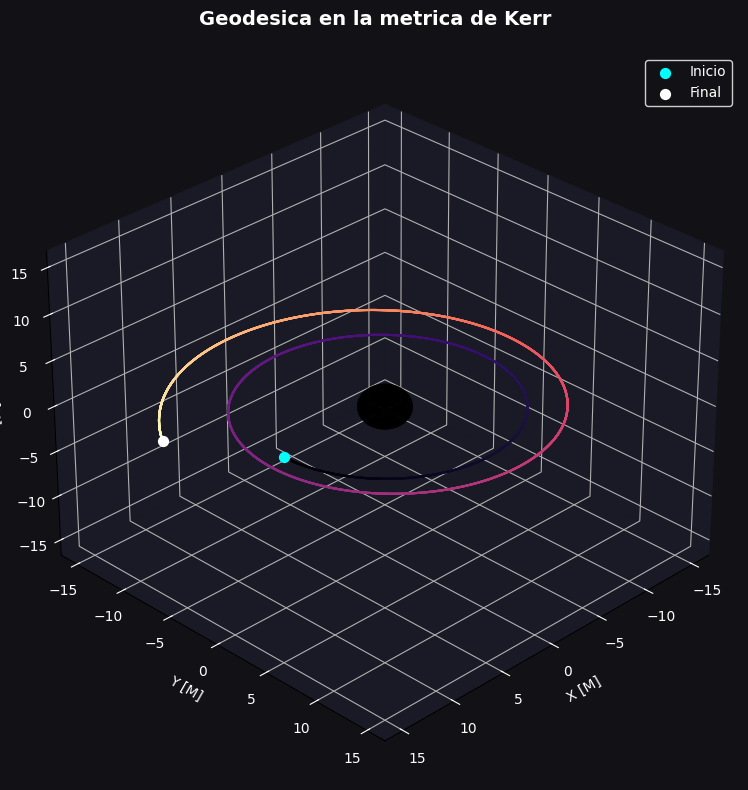

In [26]:
# Grafica 3D de la geodesica en Kerr
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=30, azim=45)

cmap = plt.get_cmap("magma")
for i in range(N_kerr - 1):
    ax.plot(x_kerr[i:i+2], y_kerr[i:i+2], z_kerr[i:i+2],
            color=cmap(i / N_kerr), alpha=0.9, linewidth=1.5)

ax.scatter(x_kerr[0], y_kerr[0], z_kerr[0], color="cyan", s=50, label="Inicio", zorder=5)
ax.scatter(x_kerr[-1], y_kerr[-1], z_kerr[-1], color="white", s=50, label="Final", zorder=5)

rs_kerr = 2.0 * M_val
u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_kerr * np.outer(np.cos(u), np.sin(v))
y_bh = rs_kerr * np.outer(np.sin(u), np.sin(v))
z_bh = rs_kerr * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color="black", alpha=1.0, zorder=10)

ax.set_facecolor("#111116")
fig.patch.set_facecolor("#111116")
ax.xaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.yaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))
ax.zaxis.set_pane_color((0.1, 0.1, 0.15, 1.0))

ax.set_xlabel("X [M]", color="white")
ax.set_ylabel("Y [M]", color="white")
ax.set_zlabel("Z [M]", color="white")
ax.tick_params(colors="white")

lim = max(np.max(np.abs(x_kerr)), np.max(np.abs(y_kerr))) * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title("Geodesica en la metrica de Kerr", color="white", fontsize=14, fontweight="bold", pad=20)
ax.legend(loc="upper right", facecolor="#111116", edgecolor="white", labelcolor="white")

plt.tight_layout()
plt.show()

In [27]:
# Integracion de 500 particulas en Kerr
N_particulas_kerr = 500
r_min_kerr = 6.0 * M_val
r_max_kerr = 20.0 * M_val

resultados_kerr_x = []
resultados_kerr_y = []
resultados_kerr_z = []
radios_kerr = []

for i in range(N_particulas_kerr):
    r0 = np.random.uniform(r_min_kerr, r_max_kerr)
    phi0 = np.random.uniform(0.0, 2.0 * np.pi)
    theta0 = np.pi / 2

    Ur0 = 0.0
    Utheta0 = 0.0
    Uphi0 = np.sqrt(M_val / r0) / r0

    Rs_val = 2.0 * M_val
    rho0 = r0**2 + a_val**2 * np.cos(theta0)**2
    Delta0 = r0**2 - Rs_val * r0 + a_val**2

    g_tt = 1.0 - Rs_val * r0 / rho0
    g_rr = -rho0 / Delta0
    g_thth = -rho0
    g_phph = -(r0**2 + a_val**2 + (Rs_val * r0 * a_val**2 * np.sin(theta0)**2) / rho0) * np.sin(theta0)**2
    g_tphi = Rs_val * r0 * a_val * np.sin(theta0)**2 / rho0

    A = g_tt
    B = 2.0 * g_tphi * Uphi0
    C = g_rr * Ur0**2 + g_thth * Utheta0**2 + g_phph * Uphi0**2 - 1.0

    disc = B**2 - 4.0 * A * C
    if disc < 0:
        continue
    Ut0 = (-B + np.sqrt(disc)) / (2.0 * A)

    Y0_part = [0.0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

    T_kepler_part = 2.0 * np.pi * np.sqrt(r0**3 / M_val)
    tau_final_part = 1.2 * T_kepler_part
    taus_part = np.linspace(0.0, tau_final_part, 120)

    sol_part = solve_ivp(
        edg_kerr,
        [0.0, tau_final_part],
        Y0_part,
        args=(M_val, a_val),
        t_eval=taus_part,
        method="Radau",
        rtol=1e-6,
        atol=1e-9
    )

    r_part = sol_part.y[1]
    th_part = sol_part.y[2]
    ph_part = sol_part.y[3]

    resultados_kerr_x.append(r_part * np.sin(th_part) * np.cos(ph_part))
    resultados_kerr_y.append(r_part * np.sin(th_part) * np.sin(ph_part))
    resultados_kerr_z.append(r_part * np.cos(th_part))
    radios_kerr.append(r0)

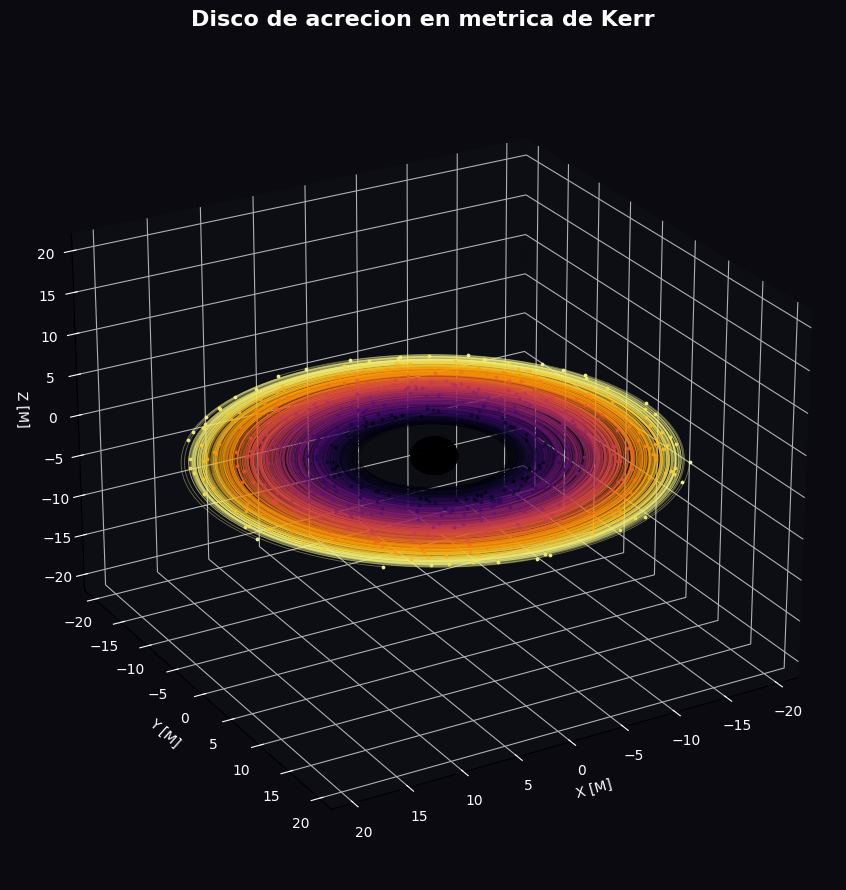

In [28]:
# Grafica 3D del disco de particulas en Kerr
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")
ax.view_init(elev=25, azim=60)

if len(radios_kerr) == 0:
    raise ValueError("No se generaron trayectorias validas para graficar.")

colores = plt.get_cmap("inferno")((np.array(radios_kerr) - r_min_kerr) / (r_max_kerr - r_min_kerr))

for i in range(len(resultados_kerr_x)):
    ax.plot(resultados_kerr_x[i], resultados_kerr_y[i], resultados_kerr_z[i],
            color=colores[i], alpha=0.4, linewidth=0.6)
    ax.scatter(resultados_kerr_x[i][-1], resultados_kerr_y[i][-1], resultados_kerr_z[i][-1],
               color=colores[i], s=3, alpha=0.9)

u = np.linspace(0, 2 * np.pi, 40)
v = np.linspace(0, np.pi, 40)
x_bh = rs_kerr * np.outer(np.cos(u), np.sin(v))
y_bh = rs_kerr * np.outer(np.sin(u), np.sin(v))
z_bh = rs_kerr * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x_bh, y_bh, z_bh, color="black", alpha=1.0, zorder=10)

ax.set_facecolor("#0a0a10")
fig.patch.set_facecolor("#0a0a10")
ax.xaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.yaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))
ax.zaxis.set_pane_color((0.05, 0.05, 0.08, 1.0))

ax.set_xlabel("X [M]", color="white")
ax.set_ylabel("Y [M]", color="white")
ax.set_zlabel("Z [M]", color="white")
ax.tick_params(colors="white")

lim = r_max_kerr * 1.1
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)
ax.set_zlim(-lim, lim)

plt.title("Disco de acrecion en metrica de Kerr", color="white", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# Dinámica de Partículas Cargadas:  Jet Astrofísico


### Unidades Electromagnéticas Absolutas y Factores de Escala

Para poder integrar la fuerza de Lorentz en nuestra simulación sin romper la escala computacional, debemos transformar las cantidades electromagnéticas del Sistema Internacional a nuestro sistema de unidades usando los factores de escala ($U_L, U_T, U_M, U_F, U_Q$).

Como se vio en clase, las unidades en electromagnetismo se pueden tratar usando la idea de Gauss de unidades absolutas. Partiendo de la ley de Coulomb:
$$F = \frac{q_1 q_2}{4\pi \epsilon_0 r^2}$$

Inventamos unas unidades en las cuales la constante desaparece:
$$F' = \frac{q'_1 q'_2}{r'^2}$$

Si escogemos un sistema de unidades base, podemos relacionar la fuerza y la carga mediante sus factores de escala $F = F' U_F$, $q = q' U_Q$, y $r = r' U_L$. Al reemplazar esto en la fuerza original obtenemos:
$$F' U_F = \frac{q'_1 U_Q q'_2 U_Q}{4\pi \epsilon_0 r'^2 U_L^2}$$

Usando el hecho de que $F' = q'_1 q'_2/r'^2$, deducimos la unidad de fuerza:
$$U_F = \frac{U_Q U_Q}{4\pi \epsilon_0 U_L^2}$$

Despejando, las unidades de carga en este sistema son:
$$U_Q = U_L \sqrt{U_F 4\pi\epsilon_0}$$

**Unidad de Campo Magnético ($U_B$)**
Para simular el jet, necesitamos el campo magnético. De la fuerza magnética clásica $F = qvB$, y sabiendo que la velocidad escala con $c$ ($U_V = c$), deducimos el factor de escala para el campo magnético:
$$U_F = U_Q c U_B \implies U_B = \frac{U_F}{U_Q c}$$

Con estos factores definidos, cualquier cantidad física (como la masa $m$, la carga $q$ o el campo $B_0$) se puede convertir a nuestro sistema adimensional dividiéndola por su respectiva unidad fundamental (ej. $q' = q / U_Q$). Esto nos permitirá calcular el factor de acoplamiento de la fuerza de Lorentz directamente de los valores reales del electrón y del entorno del agujero negro.


In [29]:
# Constantes Fundamentales (SI)
c = const.c                   # Velocidad de la luz [m/s]
eps0 = const.eps0             # Permitividad del vacío [F/m]
M_sol = M_sol = const.M_sun   # Masa solar [kg]
G_c = const.G

# Masa del agujero negro 
MAGN = 10.0 * M_sol

# 1. Factores de Escala Mecánicos
UM = MAGN
UL = (G_c * UM) / c**2  
UT = UL / c

# Unidade derivadas 

UV = UL / UT
UA = UL / UT**2
UF = UM * UA

# Uidades Gaussianas 

UQ = UL * np.sqrt(UF * 4*np.pi*eps0)
UE = UF / UQ
UB = UE / UV 

# Prpiedades del electrom 

e = 1.60217663e-19
me = const.m_e

# Conversión a unidades de simulación (adimensionales o normalizadas)

q_sim = e / UQ
m_sim = me / UM

### El Tensor de Campo Electromagnetico (Tensor de Faraday)

Para incorporar la interaccion de particulas cargadas con un campo electromagnetico en espacio-tiempo curvo, introducimos el tensor de Faraday $F_{\mu\nu}$. Es un tensor antisimetrico de rango 2 que unifica los campos electrico y magnetico en una sola entidad covariante.

**1. Definicion tensorial**
En un sistema de coordenadas general $x^\mu = (t, r, \theta, \phi)$, el tensor covariante se define a partir del cuadripotencial $A_\mu = (-\Phi, \vec{A})$:
$$F_{\mu\nu} = \partial_\mu A_\nu - \partial_\nu A_\mu = A_{\nu;\mu} - A_{\mu;\nu}$$
Por definicion, cumple $F_{\mu\nu} = -F_{\nu\mu}$. Las componentes $F_{t i}$ representan el campo electrico y las componentes $F_{i j}$ representan el campo magnetico.

**2. Representacion matricial**
En la base $(t, r, \theta, \phi)$ y en unidades gaussianas, la forma covariante es:
$$F_{\mu\nu} = \begin{pmatrix}0 & -E_r & -E_\theta & -E_\phi \\ E_r & 0 & B_\phi & -B_\theta \\ E_\theta & -B_\phi & 0 & B_r \\ E_\phi & B_\theta & -B_r & 0\end{pmatrix}$$

Donde $E_i$ y $B_i$ son las componentes coordinadas de los campos electromagneticos del jet.



### El Tensor de Faraday en la Métrica de Schwarzschild

Para acoplar el electromagnetismo a las ecuaciones globales de movimiento (geodésicas cargadas) en un espacio-tiempo curvo, es necesario transformar las **componentes físicas** locales del campo (medidas por un observador local, denotadas con $\hat{\mu}$) a **componentes coordinadas** globales ($F_{\mu\nu}$).

#### 1. Factores de Escala de Schwarzschild
En unidades geometrizadas ($G = c = 1$, $r_s = 2M$), los factores de escala geométricos $h_\mu = \sqrt{|g_{\mu\mu}|}$ asociados a las coordenadas espaciales $(r, \theta, \phi)$ son:

$$h_r = \frac{1}{\sqrt{1 - \frac{r_s}{r}}}, \quad h_\theta = r, \quad h_\phi = r \sin\theta$$

#### 2. Campos Magnéticos Helicoidales (Base Local)
Modelamos un campo puramente magnético ($E_{\hat{\mu}} = 0$) con componentes físicas helicoidales dadas por:
$$B_{\hat{r}} = B_0 \cos\theta, \quad B_{\hat{\theta}} = -B_0 \sin\theta, \quad B_{\hat{\phi}} = \frac{B_1}{r \sin\theta}$$

#### 3. Tensor de Faraday Covariante $F_{\mu\nu}$
Dado que la transformación entre la base ortonormal plana y la base coordinada es diagonal, las componentes del tensor se relacionan directamente mediante los factores de escala: $F_{\mu\nu} = h_\mu h_\nu F_{\hat{\mu}\hat{\nu}}$. 

Expandiendo la matriz con la convención de signos antisimétricos adoptada, el tensor final con índices abajo que se acopla a la fuerza de Lorentz es:

$$F_{\mu\nu} = \begin{pmatrix} 
0 & 0 & 0 & 0 \\ 
0 & 0 & h_r h_\theta B_{\hat{\phi}} & -h_r h_\phi B_{\hat{\theta}} \\ 
0 & -h_r h_\theta B_{\hat{\phi}} & 0 & h_\theta h_\phi B_{\hat{r}} \\ 
0 & h_r h_\phi B_{\hat{\theta}} & -h_\theta h_\phi B_{\hat{r}} & 0 
\end{pmatrix}$$

Este formalismo asegura que la contracción espacial y los efectos gravitacionales cerca del horizonte de sucesos ($r \to r_s$, donde $h_r \to \infty$) afecten correctamente la intensidad del campo magnético en la simulación.

In [40]:
def tensor_faraday_esferico_helicoidal(B0, B1, r, theta, phi, M):
    # En coordenadas esféricas (t, r, theta, phi)
    E_r = E_theta = E_phi = 0 
    
    # 1. Componentes FÍSICAS del campo magnético helicoidal
    B_hat_r = B0 * np.cos(theta)
    B_hat_theta = -B0 * np.sin(theta)
    B_hat_phi = B1 / (r * np.sin(theta) + 1e-12) 
    
    # 2. Factores de escala métricos de Schwarzschild usando la M real
    rs = 2.0 * M
    h_r = 1.0 / np.sqrt(np.abs(1.0 - rs / r) + 1e-12)
    h_theta = r
    h_phi = r * np.sin(theta)
    
    # 3. Conversión a componentes coordinadas
    F_r_theta = h_r * h_theta * B_hat_phi
    F_r_phi   = h_r * h_phi * B_hat_theta
    F_theta_phi = h_theta * h_phi * B_hat_r
    
    # 4. Construcción del tensor F_mu_nu covariante
    F = np.array([
        [0,       -E_r,        -E_theta,       -E_phi],
        [E_r,      0,           F_r_theta,     -F_r_phi],
        [E_theta, -F_r_theta,   0,              F_theta_phi],
        [E_phi,    F_r_phi,    -F_theta_phi,    0]
    ])
    
    return F

### Ecuacion de Movimiento: Fuerza de Lorentz en Espacio-Tiempo Curvo

El movimiento de una particula de masa $m$ y carga $q$ en un campo gravitacional y electromagnetico se describe con la **geodesica cargada**. Usando la metrica de Schwarzschild y unidades geometrizadas ($G=c=1$), la ecuacion covariante es:

$$\frac{dU^\mu}{d\tau} + \Gamma^\mu_{\alpha\beta} U^\alpha U^\beta = \frac{q}{m} F^\mu_{\ \nu} U^\nu$$

Para el integrador numerico, la forma de primer orden queda:

$$\frac{dx^\mu}{d\tau} = U^\mu$$
$$\frac{dU^\mu}{d\tau} = -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta + \frac{q}{m} F^\mu_{\ \nu} U^\nu$$

Aqui $\Gamma^\mu_{\alpha\beta}$ son los simbolos de Christoffel de Schwarzschild, y el tensor mixto se obtiene como $F^\mu_{\ \nu} = g^{\mu\alpha} F_{\alpha\nu}$.

In [33]:
import sympy as sm
import einsteinpy.symbolic as es
import numpy as np

# 1. Variables simbólicas
t, r, theta, phi = sm.symbols('t r theta phi')
M_sym = sm.symbols('M')
coords = [t, r, theta, phi]

# 2. Métrica de Schwarzschild (Métrica base)
r_s = 2 * M_sym
f_schwarz = 1 - r_s / r
metric_matrix = [
    [-f_schwarz, 0, 0, 0],
    [0, 1 / f_schwarz, 0, 0],
    [0, 0, r**2, 0],
    [0, 0, 0, r**2 * sm.sin(theta)**2]
]

# 3. Componentes geométricas con EinsteinPy (Para los Christoffel)
g_sym = es.MetricTensor(metric_matrix, coords)
chris_sym = es.ChristoffelSymbols.from_metric(g_sym) 

# 4. SOLUCCIÓN DEFINITIVA: Inversa calculada directamente con SymPy
# Convertimos la lista en una Matrix de SymPy y calculamos su inversa con .inv()
g_inv_matrix = sm.Matrix(metric_matrix).inv()

# 5. Convertir a funciones numéricas de NumPy usando lambdify
evaluar_christoffel = sm.lambdify((r, theta, M_sym), chris_sym.tensor(), 'numpy')
evaluar_g_inv = sm.lambdify((r, theta, M_sym), g_inv_matrix, 'numpy')

In [41]:
def ecuacion_movimiento(tau, Y, M, q, m, B0, B1):
    """
    Ecuación de movimiento acoplada utilizando el tensor de Faraday covariante 
    y la geometría calculada numéricamente desde EinsteinPy.
    """
    # 1. Desempaquetar el vector de estado
    x = Y[0:4]       # Posición: [t, r, theta, phi]
    U = Y[4:8]       # Cuadrivelocidad: [Ut, Ur, Utheta, Uphi]
    
    r_val, theta_val = x[1], x[2]
    
    # 2. Evaluar la geometría de Schwarzschild forzando el tipo de dato a float puro
    Gamma = np.array(evaluar_christoffel(r_val, theta_val, M)).astype(float)
    g_inv = np.array(evaluar_g_inv(r_val, theta_val, M)).astype(float)
    
    # 3. Calcular tu Tensor de Faraday covariante pasando la M
    F_cov = tensor_faraday_esferico_helicoidal(B0, B1, r_val, theta_val, x[3], M)
    
    # 4. Elevar el primer índice usando la métrica inversa: F^mu_nu = g^mu_alpha * F_alpha_nu
    F_mixto = g_inv @ F_cov
    
    # 5. Evolución de la posición: dx^mu / dtau = U^mu
    dpos_dtau = U
    
    # 6. Fuerza Gravitacional (Geodésica): -\Gamma^\mu_{\alpha\beta} U^\alpha U^\beta
    termino_gravitacional = -np.einsum('mab,a,b->m', Gamma, U, U)
    
    # 7. Fuerza Electromagnética (Lorentz): (q/m) * F^\mu_\nu * U^\nu
    termino_electromagnetico = (q / m) * (F_mixto @ U)
    
    # 8. Evolución de la velocidad: dU^mu / dtau
    dvel_dtau = termino_gravitacional + termino_electromagnetico
    
    # Retornar un arreglo continuo de 8 elementos de tipo float64 para solve_ivp
    return np.concatenate([dpos_dtau, dvel_dtau]).astype(float)

In [42]:
from scipy.integrate import solve_ivp

# ==========================================
# 1. PARÁMETROS DEL SISTEMA (En unidades de simulación)
# ==========================================
# Masa del agujero negro normalizada (visto en tu primera celda)
M_val = 1.0  
rs_val = 2.0 * M_val

# Propiedades de la partícula (Usando los factores que calculaste al inicio)
# q_sim y m_sim deben venir de tu celda de unidades. Si no las tienes corriendo ahí,
# puedes usar valores de prueba como q_particula = 1.0 y m_particula = 1.0 para probar la órbita.
q_particula = q_sim  
m_particula = m_sim  

# Intensidades del campo magnético del jet (ajustables)
B0_val = 0.1   # Campo poloidal (vertical)
B1_val = 0.05  # Campo toroidal (helicoidal)

# ==========================================
# 2. POSICIÓN INICIAL x^\mu = (t, r, \theta, \phi)
# ==========================================
t0 = 0.0
r0 = 4.0        # Lanzada a una distancia segura fuera del horizonte (r > 2)
theta0 = np.pi / 4.0  # Ángulo intermedio (45 grados) para que sienta el jet helicoidal
phi0 = 0.0      # Ángulo azimutal inicial

# ==========================================
# 3. CUADRIVELOCIDAD INICIAL U^\mu y NORMALIZACIÓN
# ==========================================
# Definimos primero las velocidades espaciales que deseamos
Ur0 = 0.1       # Se mueve hacia afuera (componente radial)
Utheta0 = 0.01  # Pequeño impulso latitudinal
Uphi0 = 0.05    # Componente de rotación alrededor del agujero negro

# Evaluamos los componentes de la métrica en la posición inicial para despejar U^t
f_ini = 1.0 - rs_val / r0
g_tt = -f_ini
g_rr = 1.0 / f_ini
g_thth = r0**2
g_phph = r0**2 * np.sin(theta0)**2

# Despejamos Ut0 a partir de: g_tt*(U^t)^2 + g_rr*(U^r)^2 + g_thth*(U^\theta)^2 + g_phph*(U^\phi)^2 = -1
suma_espacial = g_rr * Ur0**2 + g_thth * Utheta0**2 + g_phph * Uphi0**2
Ut0 = np.sqrt(( -1.0 - suma_espacial ) / g_tt)

# Construimos el vector de estado inicial completo (8 componentes)
Y0 = [t0, r0, theta0, phi0, Ut0, Ur0, Utheta0, Uphi0]

print("Vector de estado inicial acoplado con éxito:")
print(f"Posición inicial: [t={t0:.2f}, r={r0:.2f}, theta={theta0:.2f}, phi={phi0:.2f}]")
print(f"Cuadrivelocidad normalizada: [Ut={Ut0:.4f}, Ur={Ur0:.4f}, Utheta={Utheta0:.4f}, Uphi={Uphi0:.4f}]")

Vector de estado inicial acoplado con éxito:
Posición inicial: [t=0.00, r=4.00, theta=0.79, phi=0.00]
Cuadrivelocidad normalizada: [Ut=1.4433, Ur=0.1000, Utheta=0.0100, Uphi=0.0500]


In [43]:
# ==========================================
# 4. CONFIGURACIÓN DEL TIEMPO PROPIO Y SIMULACIÓN
# ==========================================
tau_start = 0.0
tau_end = 200.0                       # Duración total del seguimiento de la partícula
tau_eval = np.linspace(tau_start, tau_end, 5000) # Puntos donde guardaremos la trayectoria

# Tuplas con los argumentos fijos que requiere la ecuación de movimiento
argumentos_fisicos = (M_val, q_particula, m_particula, B0_val, B1_val)

# Ejecución del integrador numérico
solucion = solve_ivp(
    fun=ecuacion_movimiento,
    t_span=(tau_start, tau_end),
    y0=Y0,
    args=argumentos_fisicos,
    method='RK45',
    t_eval=tau_eval,
    rtol=1e-8,
    atol=1e-10
)

# Guardamos los resultados si la integración fue exitosa
if solucion.success:
    print(f"¡Integración completada con éxito! Se generaron {solucion.y.shape[1]} puntos de trayectoria.")
    
    # Extraemos las posiciones coordinadas para graficar más adelante
    t_sol = solucion.y[0]
    r_sol = solucion.y[1]
    theta_sol = solucion.y[2]
    phi_sol = solucion.y[3]
else:
    print("Hubo un problema con la integración numérica:", solucion.message)

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Transformación de Coordenadas Esféricas a Cartesianas (Físicas)
# Usamos las soluciones numéricas guardadas de la celda anterior
x_cart = r_sol * np.sin(theta_sol) * np.cos(phi_sol)
y_cart = r_sol * np.sin(theta_sol) * np.sin(phi_sol)
z_cart = r_sol * np.cos(theta_sol)

# 2. Configuración de la figura 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 3. Dibujar el Agujero Negro (Horizonte de Sucesos en r = 2M)
# Creamos una esfera matemática central para dar contexto físico
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)
rs_grafica = 2 * M_val

x_bh = rs_grafica * np.outer(np.cos(u), np.sin(v))
y_bh = rs_grafica * np.outer(np.sin(u), np.sin(v))
z_bh = rs_grafica * np.outer(np.ones(np.size(u)), np.cos(v))

# Pintamos el horizonte de sucesos de color negro esférico
ax.plot_surface(x_bh, y_bh, z_bh, color='black', alpha=0.8, label='Horizonte de Sucesos ($r_s$)')

# 4. Graficar la trayectoria de la partícula cargada
# El código de colores (colormap) nos permite ver la evolución temporal o del radio
sc = ax.scatter(x_cart, y_cart, z_cart, c=r_sol, cmap='plasma', s=2, label='Trayectoria de la partícula')
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label('Distancia radial ($r$)', fontsize=12)

# Línea continua para acentuar el recorrido helicoidal
ax.plot(x_cart, y_cart, z_cart, color='cyan', linewidth=1, alpha=0.6)

# Marcar el punto de inicio del lanzamiento
ax.scatter([x_cart[0]], [y_cart[0]], [z_cart[0]], color='red', s=40, marker='o', label='Punto de Inyección')

# 5. Estética de los ejes y etiquetas
ax.set_xlabel('X ($G=c=1$)', fontsize=11)
ax.set_ylabel('Y ($G=c=1$)', fontsize=11)
ax.set_zlabel('Z ($G=c=1$)', fontsize=11)
ax.set_title('Órbita de una Partícula Cargada en un Jet Helicoidal\nAlrededor de un Agujero Negro de Schwarzschild', fontsize=13, pad=20)

# Ajustar límites de los ejes para que el agujero negro no se vea deformado
max_range = np.array([x_cart.max()-x_cart.min(), y_cart.max()-y_cart.min(), z_cart.max()-z_cart.min()]).max() / 2.0
mid_x = (x_cart.max()+x_cart.min()) * 0.5
mid_y = (y_cart.max()+y_cart.min()) * 0.5
mid_z = (z_cart.max()+z_cart.min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

ax.view_init(elev=25, azim=45) # Ángulo de perspectiva inicial óptimo
plt.legend(loc='upper left')
plt.show()

# Prompts para la ayuda de la IA 


1. en la celda de texto tengo la teoria, con ecuaciones que usea para escribir codigo en python, puedes ayudarme a hacer una mejor redacción

2. para cada una de las metricas yo ya hice la simulacion para una sola particula, puedes ayudarme a crear la simulacion para multiples particulas 

3. ayudame a comentar la celdas codigo, ya que he ido escribiendo y se me ha olvidado escribir los comentarios 

4. ayudame a corregir el error que tengo en la ecuacion de Kerr pues me arroja un error y no lo he podido encontrar 

5. en la simulacion del Jet estoy teniendoun error en el calculo de los simbolos de christofell puedes ayudarme a corregirlo 
